# Tratamento de Valores Ausentes e Outliers
## Dataset: Tráfego IoT — CTU Honeypot

**Projeto:** Detecção Segura de Dispositivos IoT  
**Dataset:** `dataset_balanceado.csv`

---

### Objetivos
1. Identificar e tratar **valores ausentes** presentes no dataset
2. Detectar e tratar **outliers** nas variáveis numéricas
3. Gerar um dataset limpo para uso nas etapas de modelagem

---

In [ ]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

DATASET_PATH = Path("../data/dataset_balanceado.csv")
OUTPUT_PATH  = Path("../data/dataset_limpo.csv")
SAMPLE_N     = 600_000
RANDOM_STATE = 42

---
## 1. Carregamento e Inspeção Inicial

In [ ]:
df_full = pd.read_csv(
    DATASET_PATH,
    low_memory=False,
)

benign_mask = df_full["label"].str.lower() == "benign"
df_full.loc[benign_mask, "label"] = "Benign"

print(f"Shape completo: {df_full.shape}")

df = df_full.sample(n=SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Shape da amostra: {df.shape}")
print(df.head(3))
print(df.tail(3))

Shape completo: (16457968, 24)
Shape da amostra: (300000, 24)
             ts                 uid      id.orig_h  id.orig_p      id.resp_h  id.resp_p proto service duration  \
0  1.545348e+09  CJl3rt2dQ36uwlmKOh  192.168.1.197      38114  124.197.68.91       8081   tcp       -        -   
1  1.547148e+09  CtRvpb4G3LhJkTcn6k  192.168.1.198      10803    213.87.5.55         23   tcp       -        -   
2  1.545481e+09  C9udgy40w5gynuKyjg  192.168.1.198      36097  193.93.251.33      37215   tcp       -        -   

  orig_bytes resp_bytes conn_state local_orig local_resp  missed_bytes history  orig_pkts  orig_ip_bytes  resp_pkts  \
0          -          -         S0          -          -             0       S          1             40          0   
1          -          -         S0          -          -             0       S          1             40          0   
2          -          -         S0          -          -             0       S          1             40          0   

   r

In [76]:
print("=== Tipos de dados ===")
print(df.dtypes)
print("\n=== Distribuição do label ===")
print(df["label"].value_counts())

=== Tipos de dados ===
ts                float64
uid                   str
id.orig_h             str
id.orig_p           int64
id.resp_h             str
id.resp_p           int64
proto                 str
service               str
duration              str
orig_bytes            str
resp_bytes            str
conn_state            str
local_orig            str
local_resp            str
missed_bytes        int64
history               str
orig_pkts           int64
orig_ip_bytes       int64
resp_pkts           int64
resp_ip_bytes       int64
tunnel_parents        str
label                 str
detailed-label        str
scenario              str
dtype: object

=== Distribuição do label ===
label
Malicious    255165
Benign        44835
Name: count, dtype: int64


---
## 2. Tratamento de Valores Ausentes

No formato Zeek/Bro (usado para gerar logs de rede), o caractere **`-`** é o indicador padrão de valor ausente/desconhecido.  
Antes de qualquer análise, precisamos substituí-lo por `NaN` para que o pandas o reconheça corretamente.

### 2.1 Identificação

In [ ]:
df.replace("-", np.nan, inplace=True)

missing = (
    df.isnull()
    .sum()
    .rename("qtd_nulos")
    .to_frame()
)
missing["pct_nulos"] = (missing["qtd_nulos"] / len(df) * 100).round(2)
missing = missing[missing["qtd_nulos"] > 0].sort_values("pct_nulos", ascending=False)

print(f"Colunas com valores ausentes: {len(missing)} / {df.shape[1]}")
display(missing)

Colunas com valores ausentes: 9 / 24


,qtd_nulos,pct_nulos
local_orig,300000,100.00
local_resp,300000,100.00
service,299432,99.81
tunnel_parents,279780,93.26
duration,212678,70.89
resp_bytes,212678,70.89
orig_bytes,212678,70.89
detailed-label,44835,14.94
history,601,0.20


### 2.2 Visualização dos Valores Ausentes

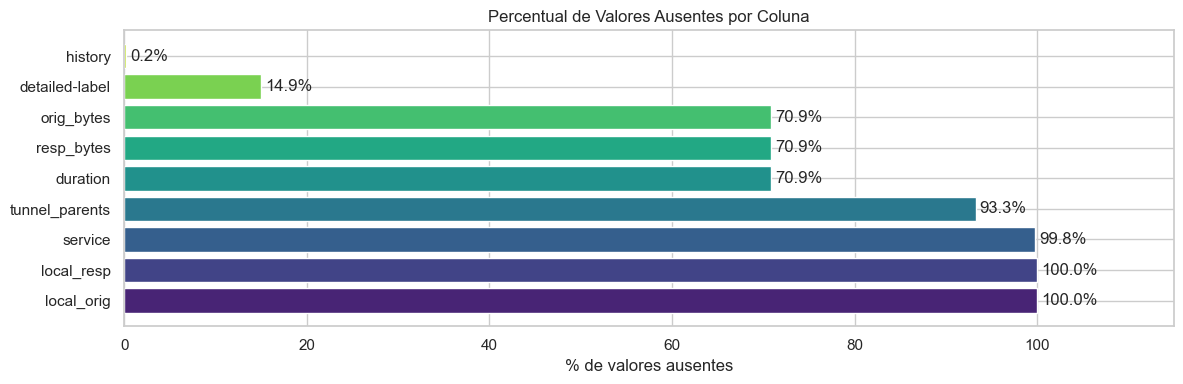

In [ ]:
if not missing.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.barh(
        missing.index,
        missing["pct_nulos"],
        color=sns.color_palette("viridis", len(missing)),
    )
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Percentual de Valores Ausentes por Coluna")
    ax.set_xlim(0, missing["pct_nulos"].max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor ausente encontrado após substituição de '-'.")

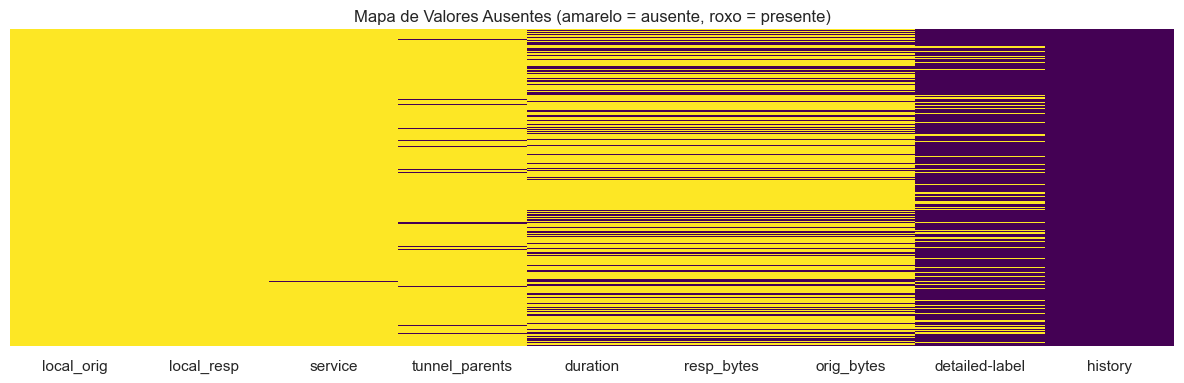

In [79]:
# Heatmap de ausência (amostra menor para performance)
subset_cols = missing.index.tolist()
if subset_cols:
    sample_vis = df[subset_cols].sample(n=min(5_000, len(df)), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        sample_vis.isnull(),
        cbar=False,
        yticklabels=False,
        cmap="viridis",
        ax=ax,
    )
    ax.set_title("Mapa de Valores Ausentes (amarelo = ausente, roxo = presente)")
    plt.tight_layout()
    plt.show()

### 2.3 Estratégias de Tratamento

O tratamento é aplicado **dinamicamente** a todas as colunas com valores ausentes, sem hardcoding de nomes.
A estratégia é determinada pela natureza de cada coluna:

| Tipo detectado | Estratégia | Justificativa |
|---|---|---|
| **`object` + conteúdo numérico** | Converter para `float` | Zeek salva `'-'` onde deveria ser número; após substituição fica `object` |
| **Numérica com `bytes`/`pkts` no nome** | Preencher com **`0`** | Ausência = nenhum dado transferido |
| **Numérica demais** | Preencher com **mediana** | Robusta a outliers |
| **`local_orig`, `local_resp`** | **Remover colunas** | Apenas valores ausentes — sem informação utilizável |
| **Categórica geral** | Preencher com **`'unknown'`** | Ausência tem significado próprio no contexto de rede |
| **% ausente > 90%** | **Remover coluna** | Sem valor preditivo |


In [80]:
df_clean = df.copy()

# ------------------------------------------------------------------
# 1) Colunas a remover: pct > 90% e sem valor para modelagem
# ------------------------------------------------------------------
cols_to_drop = missing[missing["pct_nulos"] > 90].index.tolist()
cols_to_drop += [c for c in ["uid", "ts", "local_orig", "local_resp"] if c in df_clean.columns and c not in cols_to_drop]
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)
print(f"Colunas removidas: {cols_to_drop}")

# ------------------------------------------------------------------
# 2) Para colunas object com nulos: tentar converter para numérico
# ------------------------------------------------------------------
obj_cols_with_na = [
    c for c in df_clean.select_dtypes(include=["object"]).columns
    if df_clean[c].isnull().any()
]

numeric_converted = []
categorical_cols  = []

for col in obj_cols_with_na:
    converted = pd.to_numeric(df_clean[col], errors="coerce")
    original_non_null  = df_clean[col].notna().sum()
    converted_non_null = converted.notna().sum()
    if converted_non_null == original_non_null:
        df_clean[col] = converted
        numeric_converted.append(col)
    else:
        categorical_cols.append(col)

print(f"Colunas object convertidas para numérico: {numeric_converted}")
print(f"Colunas object mantidas como categóricas: {categorical_cols}")

# ------------------------------------------------------------------
# 3) Colunas numéricas com nulos
#    Estratégia:
#      - bytes/pkts: 0  (ausência = nenhum dado transferido)
#      - demais:     mediana
# ------------------------------------------------------------------
num_cols_with_na = [
    c for c in df_clean.select_dtypes(include=["number"]).columns
    if df_clean[c].isnull().any()
]

bytes_pattern = ["bytes", "pkts"]

for col in num_cols_with_na:
    n_nulls = df_clean[col].isnull().sum()
    if any(p in col.lower() for p in bytes_pattern):
        df_clean[col] = df_clean[col].fillna(0)
        print(f"  '{col}' -> {n_nulls} nulos preenchidos com 0")
    else:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  '{col}' -> {n_nulls} nulos preenchidos com mediana={median_val}")

# ------------------------------------------------------------------
# 4) Colunas categóricas com nulos
#    Estratégia: 'unknown' (astype object evita falha com colunas category)
# ------------------------------------------------------------------
for col in categorical_cols:
    n_nulls = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].astype("object").fillna("unknown")
    print(f"  '{col}' -> {n_nulls} nulos preenchidos com 'unknown'")

# ------------------------------------------------------------------
# 5) Tratando a coluna de duration, se tiver como nulo, substituir
# pela mediana
# ------------------------------------------------------------------
col = "duration"
if col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    n_nulos = df_clean[col].isnull().sum()
    if n_nulos > 0:
        mediana = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(mediana)
        print(f"  '{col}' -> {n_nulos} nulos preenchidos com mediana={mediana}")

# ------------------------------------------------------------------
# Verificação final — garante cobertura completa
# ------------------------------------------------------------------
remaining_na = df_clean.isnull().sum().sum()
remaining_by_col = df_clean.isnull().sum()
remaining_by_col = remaining_by_col[remaining_by_col > 0]
print(f"Valores ausentes restantes: {remaining_na}")
if not remaining_by_col.empty:
    print("Colunas ainda com nulos (requer tratamento adicional):")
    print(remaining_by_col)
else:
    print("Nenhum valor ausente restante.")

Colunas removidas: ['local_orig', 'local_resp', 'service', 'tunnel_parents', 'uid', 'ts']
Colunas object convertidas para numérico: ['duration', 'orig_bytes', 'resp_bytes']
Colunas object mantidas como categóricas: ['history', 'detailed-label']
  'duration' -> 212678 nulos preenchidos com mediana=2e-06
  'orig_bytes' -> 212678 nulos preenchidos com 0
  'resp_bytes' -> 212678 nulos preenchidos com 0
  'history' -> 601 nulos preenchidos com 'unknown'
  'detailed-label' -> 44835 nulos preenchidos com 'unknown'
Valores ausentes restantes: 0
Nenhum valor ausente restante.


In [ ]:
print(f"Shape original da amostra : {df.shape}")
print(f"Shape após tratamento      : {df_clean.shape}")
print(f"\nColunas restantes ({df_clean.shape[1]}):")
print(df_clean.dtypes)

Shape original da amostra : (300000, 24)
Shape após tratamento      : (300000, 18)

Colunas restantes (18):
id.orig_h             str
id.orig_p           int64
id.resp_h             str
id.resp_p           int64
proto                 str
duration          float64
orig_bytes        float64
resp_bytes        float64
conn_state            str
missed_bytes        int64
history            object
orig_pkts           int64
orig_ip_bytes       int64
resp_pkts           int64
resp_ip_bytes       int64
label                 str
detailed-label     object
scenario              str
dtype: object


---
## 3. Tratamento de Outliers

Outliers são observações que se afastam significativamente do padrão da distribuição.  
No contexto de redes, **valores extremos podem ser legítimos** (ex.: transferência de arquivo muito grande) ou indicar **ataques** (flood, DDoS, scan).  
Por isso, analisaremos antes de decidir pela remoção ou winsorização.

### 3.1 Seleção das Variáveis Numéricas

In [ ]:
NUMERIC_COLS = [
    c for c in ["duration", "orig_bytes", "resp_bytes",
                "orig_pkts", "resp_pkts", "orig_ip_bytes",
                "resp_ip_bytes", "missed_bytes"]
    if c in df_clean.columns
]

# Garantir que são numéricas
df_clean[NUMERIC_COLS] = df_clean[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce")

print("Estatísticas descritivas das variáveis numéricas:")
display(df_clean[NUMERIC_COLS].describe().T.style.format("{:.2f}"))

Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
duration,300000.00,1.36,18.84,0.00,0.00,0.00,0.00,1503.14
orig_bytes,300000.00,13369985.05,679785075.85,0.00,0.00,0.00,0.00,52775940842.00
resp_bytes,300000.00,1.05,42.09,0.00,0.00,0.00,0.00,4865.00
orig_pkts,300000.00,2.27,15.25,0.00,1.00,1.00,2.00,3069.00
resp_pkts,300000.00,0.01,0.43,0.00,0.00,0.00,0.00,80.00
orig_ip_bytes,300000.00,109.47,787.70,0.00,40.00,40.00,80.00,122760.00
resp_ip_bytes,300000.00,1.74,61.75,0.00,0.00,0.00,0.00,9152.00
missed_bytes,300000.00,0.01,4.53,0.00,0.00,0.00,0.00,1432.00


### 3.2 Visualização — Boxplots e Histogramas

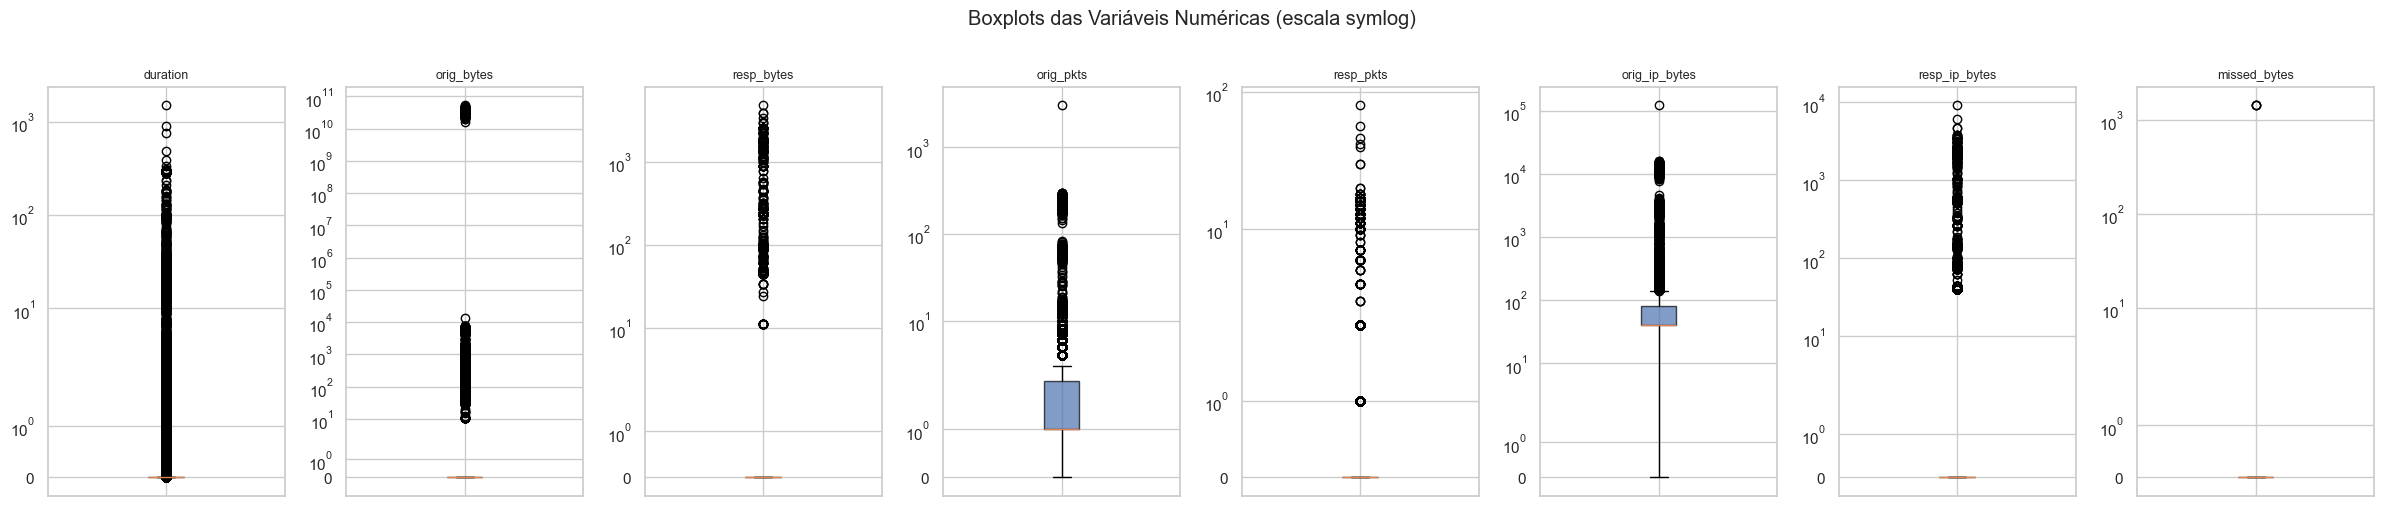

In [83]:

n_cols = len(NUMERIC_COLS)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 5))

for ax, col in zip(axes, NUMERIC_COLS):
    data = df_clean[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.7))
    ax.set_title(col, fontsize=9)
    ax.set_yscale("symlog")
    ax.set_xticklabels([])

plt.suptitle("Boxplots das Variáveis Numéricas (escala symlog)", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Detecção pelo Método IQR

O método **IQR (Intervalo Interquartil)** define outliers como valores fora do intervalo:

$$[Q1 - 1.5 \times IQR, \; Q3 + 1.5 \times IQR]$$

onde $IQR = Q3 - Q1$. É robusto porque não depende da média nem do desvio padrão.

In [84]:
def iqr_bounds(series: pd.Series, factor: float = 1.5):
    """Retorna (lower, upper) dos limites IQR."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr


iqr_summary = []
for col in NUMERIC_COLS:
    series = df_clean[col].dropna()
    lower, upper = iqr_bounds(series)
    n_outliers = ((series < lower) | (series > upper)).sum()
    pct = n_outliers / len(series) * 100
    iqr_summary.append({
        "coluna": col,
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "limite_inferior": lower,
        "limite_superior": upper,
        "n_outliers": n_outliers,
        "pct_outliers": pct,
    })

iqr_df = pd.DataFrame(iqr_summary).set_index("coluna")
display(iqr_df.style.format({
    "Q1": "{:.2f}", "Q3": "{:.2f}",
    "limite_inferior": "{:.2f}", "limite_superior": "{:.2f}",
    "pct_outliers": "{:.2f}%",
}))

,Q1,Q3,limite_inferior,limite_superior,n_outliers,pct_outliers
coluna,,,,,,
duration,0.00,0.00,0.00,0.00,43870,14.62%
orig_bytes,0.00,0.00,0.00,0.00,2992,1.00%
resp_bytes,0.00,0.00,0.00,0.00,729,0.24%
orig_pkts,1.00,2.00,-0.50,3.50,6923,2.31%
resp_pkts,0.00,0.00,0.00,0.00,1263,0.42%
orig_ip_bytes,40.00,80.00,-20.00,140.00,13450,4.48%
resp_ip_bytes,0.00,0.00,0.00,0.00,1263,0.42%
missed_bytes,0.00,0.00,0.00,0.00,3,0.00%


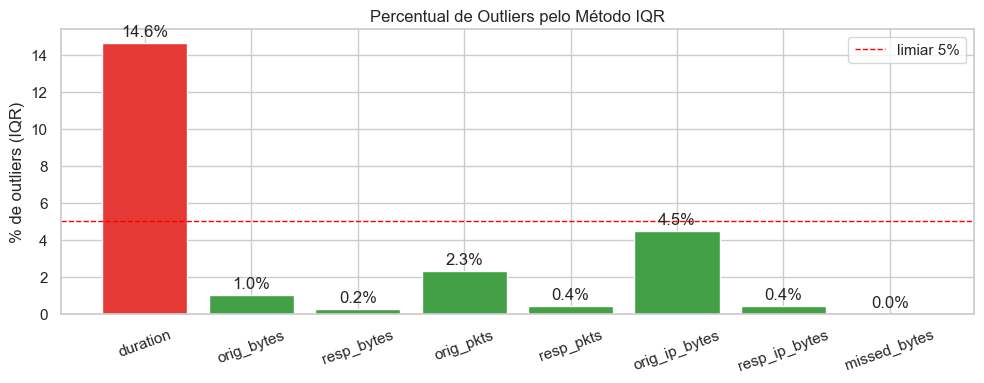

In [85]:
# Visualização: % outliers por coluna (IQR)
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#E53935" if p > 5 else "#43A047" for p in iqr_df["pct_outliers"]]
bars = ax.bar(iqr_df.index, iqr_df["pct_outliers"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(5, color="red", linestyle="--", linewidth=1, label="limiar 5%")
ax.set_ylabel("% de outliers (IQR)")
ax.set_title("Percentual de Outliers pelo Método IQR")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.4 Detecção pelo Z-Score

O **Z-score** mede quantos desvios-padrão um valor está distante da média:

$$z = \frac{x - \mu}{\sigma}$$

Valores com $|z| > 3$ são considerados outliers (equivale a ~0,3% da distribuição normal).  
**Atenção:** sensível a distribuições assimétricas — usamos como complemento ao IQR.

In [86]:
Z_THRESHOLD = 3

zscore_summary = []
for col in NUMERIC_COLS:
    series = df_clean[col].dropna()
    z = np.abs(stats.zscore(series))
    n_outliers = (z > Z_THRESHOLD).sum()
    pct = n_outliers / len(series) * 100
    zscore_summary.append({
        "coluna": col,
        "n_outliers_zscore": n_outliers,
        "pct_outliers_zscore": pct,
    })

zscore_df = pd.DataFrame(zscore_summary).set_index("coluna")
display(zscore_df.style.format({"pct_outliers_zscore": "{:.2f}%"}))

,n_outliers_zscore,pct_outliers_zscore
coluna,,
duration,1355,0.45%
orig_bytes,121,0.04%
resp_bytes,226,0.08%
orig_pkts,1278,0.43%
resp_pkts,602,0.20%
orig_ip_bytes,1291,0.43%
resp_ip_bytes,265,0.09%
missed_bytes,3,0.00%


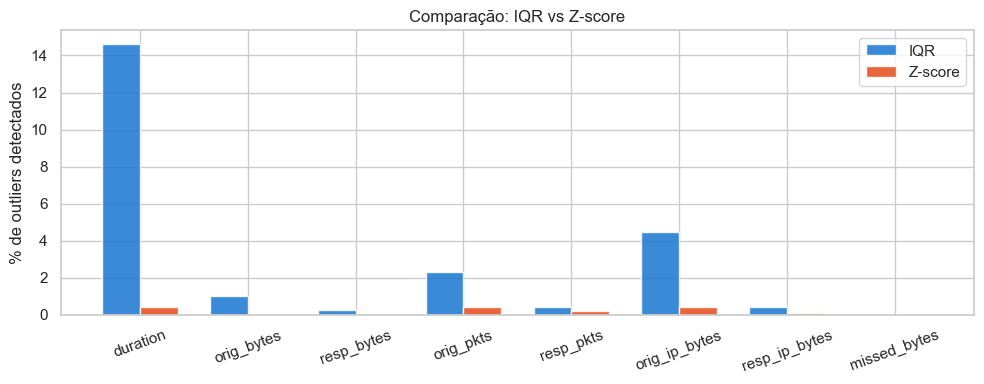

In [87]:
# Comparação IQR vs Z-score
compare = iqr_df[["pct_outliers"]].rename(columns={"pct_outliers": "IQR"}).join(
    zscore_df[["pct_outliers_zscore"]].rename(columns={"pct_outliers_zscore": "Z-score"})
)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(compare))
w = 0.35
ax.bar(x - w/2, compare["IQR"],    w, label="IQR",    color="#1976D2", alpha=0.85)
ax.bar(x + w/2, compare["Z-score"], w, label="Z-score", color="#E64A19", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=20)
ax.set_ylabel("% de outliers detectados")
ax.set_title("Comparação: IQR vs Z-score")
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 Análise de Outliers por Label

Antes de tratar, é importante entender se os outliers pertencem majoritariamente  
ao tráfego **malicioso** — nesse caso, **não devem ser removidos**, pois são features discriminativas.

In [88]:
results = []
for col in NUMERIC_COLS:
    lower, upper = iqr_bounds(df_clean[col].dropna())
    mask_outlier = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_rows = df_clean[mask_outlier]
    if len(outlier_rows) == 0:
        continue
    dist = outlier_rows["label"].value_counts(normalize=True).mul(100).round(1)
    row = {"coluna": col, "total_outliers": mask_outlier.sum()}
    for lbl, pct in dist.items():
        row[f"% {lbl}"] = pct
    results.append(row)

label_dist_df = pd.DataFrame(results).set_index("coluna").fillna(0)
display(label_dist_df)

print("\nObservacao: se outliers sao majoritariamente malicious, a Winsorização é preferível à remoção.")

,total_outliers,% Malicious,% Benign
coluna,,,
duration,43870,90.6,9.4
orig_bytes,2992,60.3,39.7
resp_bytes,729,26.9,73.1
orig_pkts,6923,96.3,3.7
resp_pkts,1263,27.7,72.3
orig_ip_bytes,13450,68.3,31.7
resp_ip_bytes,1263,27.7,72.3
missed_bytes,3,100.0,0.0



Observacao: se outliers sao majoritariamente malicious, a Winsorização é preferível à remoção.


### 3.6 Estratégias de Tratamento

| Estratégia | Descrição | Quando usar |
|---|---|---|
| **Winsorização** | Clipa nos percentis (ex.: p1–p99) | Distribuição muito assimétrica e outliers válidos |

**Decisão para este dataset:**  
Como os outliers em variáveis de bytes/pacotes frequentemente correspondem a ataques,  
aplicaremos **Winsorização nos percentis 1%–99%** para atenuar valores extremos sem perdê-los.

In [89]:
df_treated = df_clean.copy()

LOWER_PCT = 0.01
UPPER_PCT = 0.99

winsor_log = []
for col in NUMERIC_COLS:
    lower = df_treated[col].quantile(LOWER_PCT)
    upper = df_treated[col].quantile(UPPER_PCT)
    n_clipped = ((df_treated[col] < lower) | (df_treated[col] > upper)).sum()
    df_treated[col] = df_treated[col].clip(lower=lower, upper=upper)
    winsor_log.append({"coluna": col, "p1": lower, "p99": upper, "n_winsorizados": n_clipped})

winsor_df = pd.DataFrame(winsor_log).set_index("coluna")
print("Limites de winsorização aplicados:")
display(winsor_df.style.format({"p1": "{:.3f}", "p99": "{:.3f}"}))

Limites de winsorização aplicados:


,p1,p99,n_winsorizados
coluna,,,
duration,0.000,4.430,3000
orig_bytes,0.000,0.000,2992
resp_bytes,0.000,0.000,729
orig_pkts,0.000,6.000,1920
resp_pkts,0.000,0.000,1263
orig_ip_bytes,0.000,540.000,1864
resp_ip_bytes,0.000,0.000,1263
missed_bytes,0.000,0.000,3


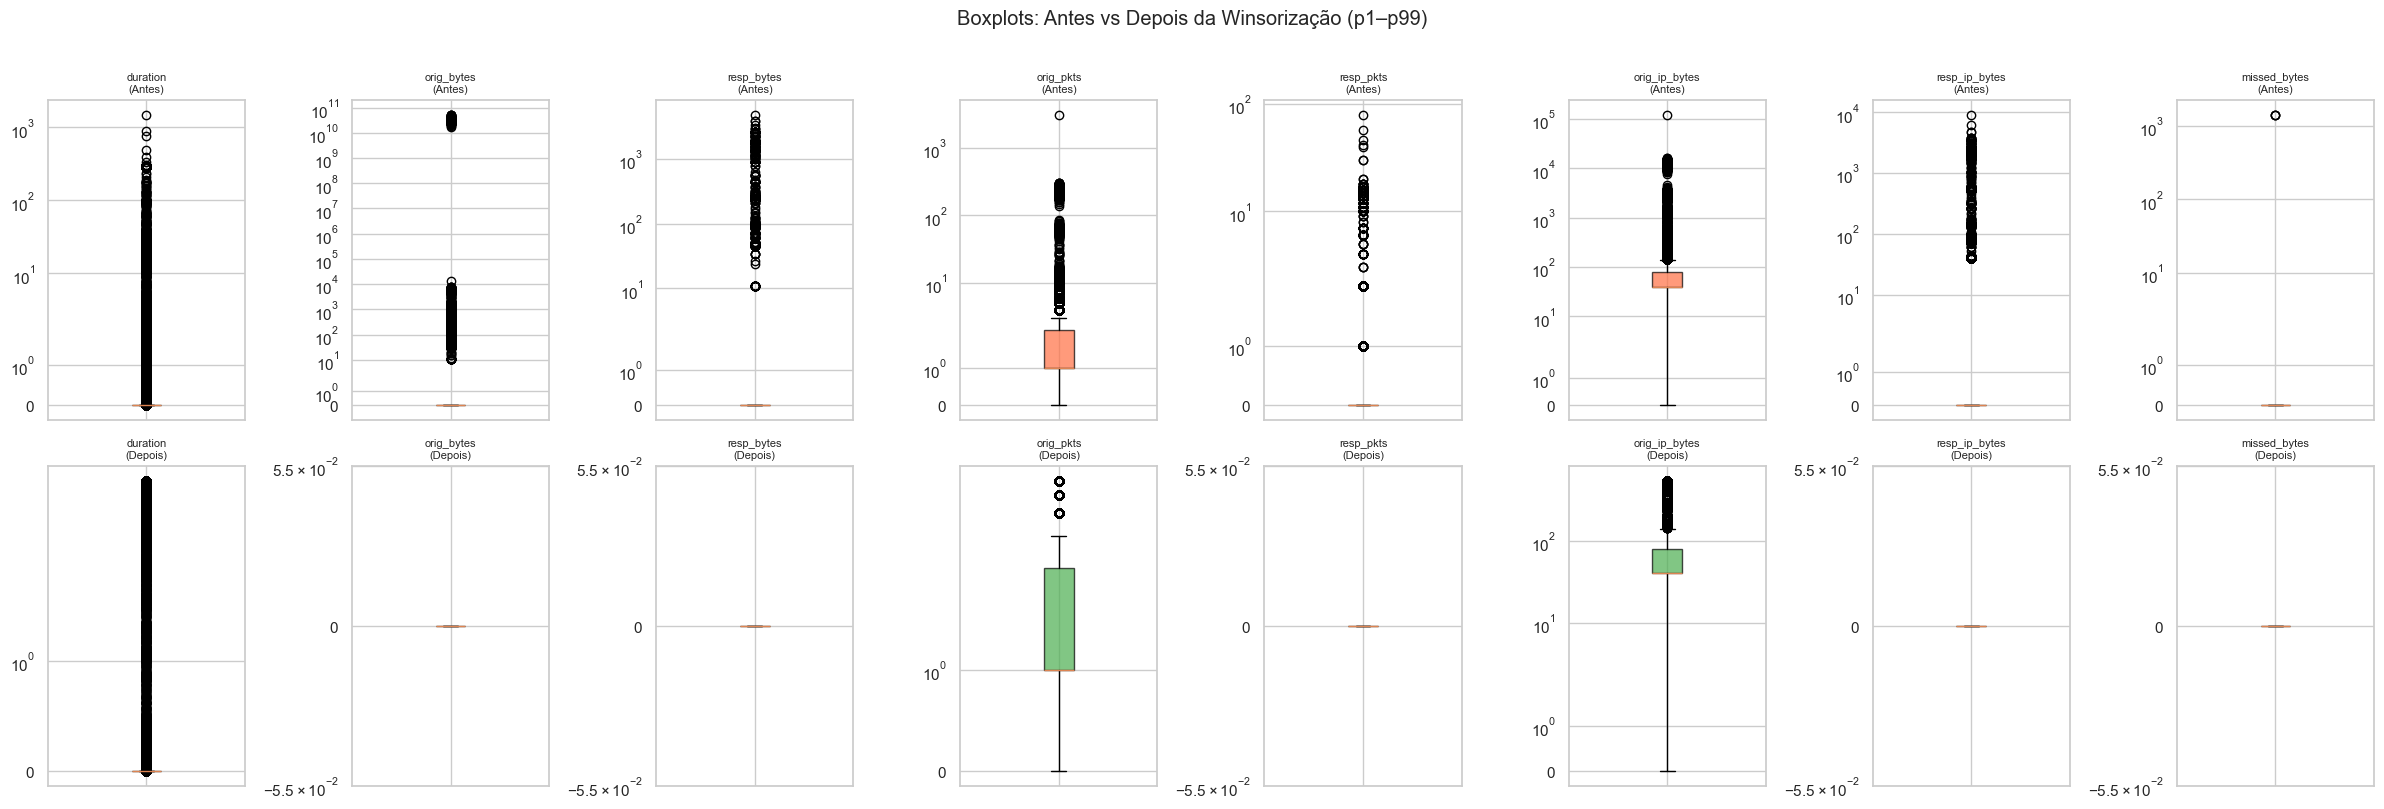

In [ ]:
fig, axes = plt.subplots(2, len(NUMERIC_COLS), figsize=(3 * len(NUMERIC_COLS), 8))

for j, col in enumerate(NUMERIC_COLS):
    for row_idx, (data, title) in enumerate([
        (df_clean[col],   "Antes"),
        (df_treated[col], "Depois"),
    ]):
        ax = axes[row_idx][j]
        ax.boxplot(data.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor="#4CAF50" if row_idx else "#FF7043", alpha=0.7))
        ax.set_title(f"{col}\n({title})", fontsize=8)
        ax.set_yscale("symlog")
        ax.set_xticklabels([])

plt.suptitle("Boxplots: Antes vs Depois da Winsorização (p1–p99)", y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Resumo Final e Exportação

In [91]:
print("=" * 60)
print("RESUMO DO PIPELINE DE LIMPEZA")
print("=" * 60)
print(f"  Linhas  : {df.shape[0]:>10,}  →  {df_treated.shape[0]:>10,}")
print(f"  Colunas : {df.shape[1]:>10}  →  {df_treated.shape[1]:>10}")
print(f"  Nulos   : {df.isnull().sum().sum():>10,}  →  {df_treated.isnull().sum().sum():>10,}")
print("\nEtapas aplicadas:")
print("  1. Substituição de '-' por NaN")
print(f"  2. Remoção de colunas: {cols_to_drop}")
print("  3. Imputação categórica (valor sentinela 'unknown')")
print("  4. Imputação numérica (mediana via SimpleImputer)")
print("  5. Winsorização p1–p99 nas variáveis numéricas")

print("\nDistribuição final dos labels:")
print(df_treated["label"].value_counts())

RESUMO DO PIPELINE DE LIMPEZA
  Linhas  :    300,000  →     300,000
  Colunas :         24  →          18
  Nulos   :  1,862,682  →           0

Etapas aplicadas:
  1. Substituição de '-' por NaN
  2. Remoção de colunas: ['local_orig', 'local_resp', 'service', 'tunnel_parents', 'uid', 'ts']
  3. Imputação categórica (valor sentinela 'unknown')
  4. Imputação numérica (mediana via SimpleImputer)
  5. Winsorização p1–p99 nas variáveis numéricas

Distribuição final dos labels:
label
Malicious    255165
Benign        44835
Name: count, dtype: int64


In [ ]:
df_treated.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset limpo salvo em: {OUTPUT_PATH.resolve()}")
df_treated.head()

Dataset limpo salvo em: C:\Users\breno\Documents\GitHub\secure-iot-detection\data\dataset_limpo.csv


,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed-label,scenario
0,192.168.1.197,38114,124.197.68.91,8081,tcp,0.000002,0.0,0.0,S0,0,S,1,40,0,0,Malicious,PartOfAHorizontalPortScan,CTU-IoT-Malware-Capture-33-1
1,192.168.1.198,10803,213.87.5.55,23,tcp,0.000002,0.0,0.0,S0,0,S,1,40,0,0,Benign,unknown,CTU-IoT-Malware-Capture-43-1
2,192.168.1.198,36097,193.93.251.33,37215,tcp,0.000002,0.0,0.0,S0,0,S,1,40,0,0,Malicious,Okiru,CTU-IoT-Malware-Capture-36-1
3,192.168.1.198,29360,92.126.29.235,23,tcp,0.000002,0.0,0.0,S0,0,S,1,40,0,0,Benign,unknown,CTU-IoT-Malware-Capture-43-1
4,192.168.1.194,53785,213.228.192.19,22,tcp,0.000002,0.0,0.0,S0,0,S,1,40,0,0,Malicious,PartOfAHorizontalPortScan,CTU-IoT-Malware-Capture-39-1
